# Notebook 08: Model Evaluation and Visualization

## Objective

This notebook evaluates the performance of the DeepTrace AI-based Cyber Threat Detection System. It computes standard classification metrics, visualizes model performance, analyzes threat and alert distributions, and generates evaluation reports for the final system.

## Input

- `/content/deeptrace_features_FINAL.csv`
- `/content/deeptrace_binary_labels_FINAL.csv`
- `/content/best_transformer_model.pth`
- `/content/deeptrace_threat_report.csv`
- `/content/deeptrace_alerts.csv`

## Output

- `reports/figures/confusion_matrix.png`
- `reports/figures/roc_curve.png`
- `reports/figures/precision_recall_curve.png`
- `reports/figures/threat_score_distribution.png`
- `reports/figures/risk_level_distribution.png`
- `reports/figures/alert_severity_distribution.png`
- `reports/metrics/classification_report.txt`
- `reports/metrics/performance_metrics.csv`
- `reports/metrics/evaluation_summary.txt`

## Workflow

Engineered Features
        ↓
Transformer Prediction
        ↓
Performance Evaluation
        ↓
Classification Metrics
        ↓
Performance Visualization
        ↓
Evaluation Reports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

In [3]:
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("reports/metrics", exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


In [4]:
features = pd.read_csv("/content/deeptrace_features_FINAL.csv")
labels = pd.read_csv("/content/deeptrace_binary_labels_FINAL.csv")
threat_report = pd.read_csv("/content/deeptrace_threat_report.csv")
alerts = pd.read_csv("/content/deeptrace_alerts.csv")

print(f"Features Shape      : {features.shape}")
print(f"Labels Shape        : {labels.shape}")
print(f"Threat Report Shape : {threat_report.shape}")
print(f"Alerts Shape        : {alerts.shape}")

Features Shape      : (239480, 49)
Labels Shape        : (239480, 1)
Threat Report Shape : (239480, 9)
Alerts Shape        : (6167, 11)


In [5]:
class DeepTraceTransformer(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        self.embedding = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)

        return self.classifier(x)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepTraceTransformer(
    input_dim=features.shape[1]
).to(device)

checkpoint = torch.load(
    "/content/best_transformer_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print(f"Device : {device}")
print("Transformer model loaded successfully.")

Device : cpu
Transformer model loaded successfully.


In [7]:
X = torch.tensor(
    features.values,
    dtype=torch.float32
).unsqueeze(1).to(device)

with torch.no_grad():
    logits = model(X)
    probabilities = torch.sigmoid(logits).cpu().numpy().flatten()

predictions = (probabilities >= 0.5).astype(int)

y_true = labels.values.flatten()

print(f"Total Samples : {len(y_true)}")
print(f"Predictions   : {len(predictions)}")

Total Samples : 239480
Predictions   : 239480


In [8]:
accuracy = accuracy_score(y_true, predictions)
precision = precision_score(y_true, predictions)
recall = recall_score(y_true, predictions)
f1 = f1_score(y_true, predictions)
roc_auc = roc_auc_score(y_true, probabilities)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(metrics_df)

metrics_df.to_csv(
    "reports/metrics/performance_metrics.csv",
    index=False
)

,Metric,Value
0,Accuracy,0.994079
1,Precision,0.882287
2,Recall,0.857686
3,F1 Score,0.869813
4,ROC-AUC,0.975091


In [9]:
report = classification_report(
    y_true,
    predictions
)

print(report)

with open(
    "reports/metrics/classification_report.txt",
    "w"
) as f:
    f.write(report)

print("Classification report saved successfully.")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    233957
           1       0.88      0.86      0.87      5523

    accuracy                           0.99    239480
   macro avg       0.94      0.93      0.93    239480
weighted avg       0.99      0.99      0.99    239480

Classification report saved successfully.


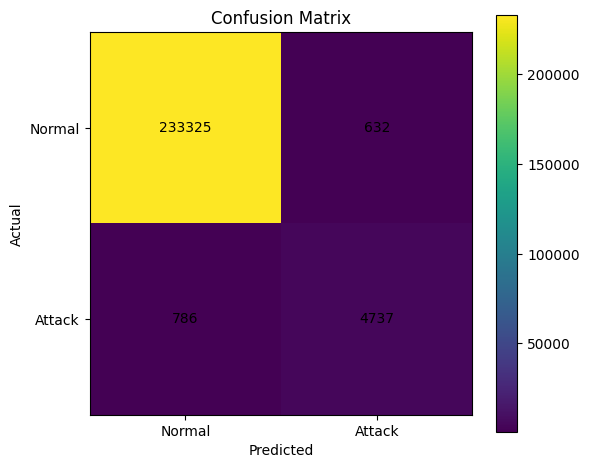

In [10]:
cm = confusion_matrix(
    y_true,
    predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "reports/figures/confusion_matrix.png",
    dpi=300
)

plt.show()

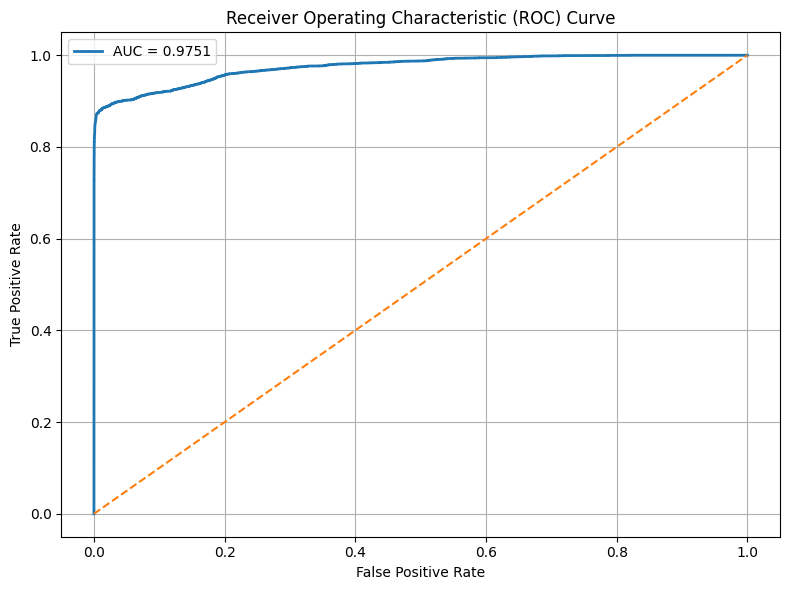

In [11]:
fpr, tpr, _ = roc_curve(y_true, probabilities)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "reports/figures/roc_curve.png",
    dpi=300
)

plt.show()

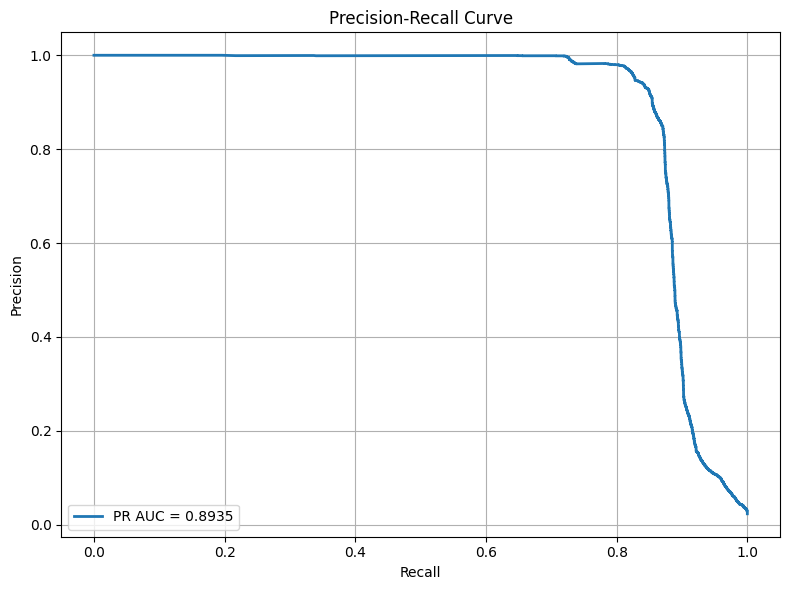

In [12]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_true,
    probabilities
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"PR AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "reports/figures/precision_recall_curve.png",
    dpi=300
)

plt.show()

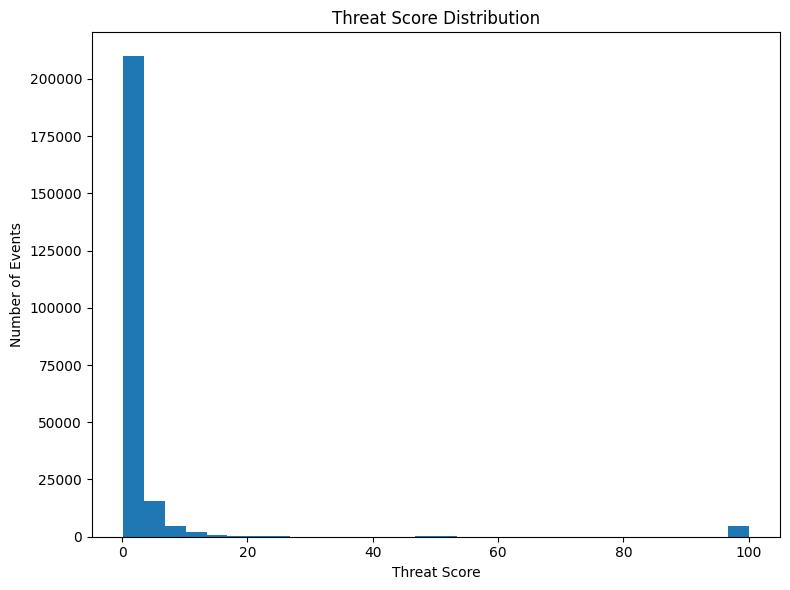

In [13]:
plt.figure(figsize=(8,6))

plt.hist(
    threat_report["ThreatScore"],
    bins=30
)

plt.xlabel("Threat Score")
plt.ylabel("Number of Events")

plt.title("Threat Score Distribution")

plt.tight_layout()

plt.savefig(
    "reports/figures/threat_score_distribution.png",
    dpi=300
)

plt.show()

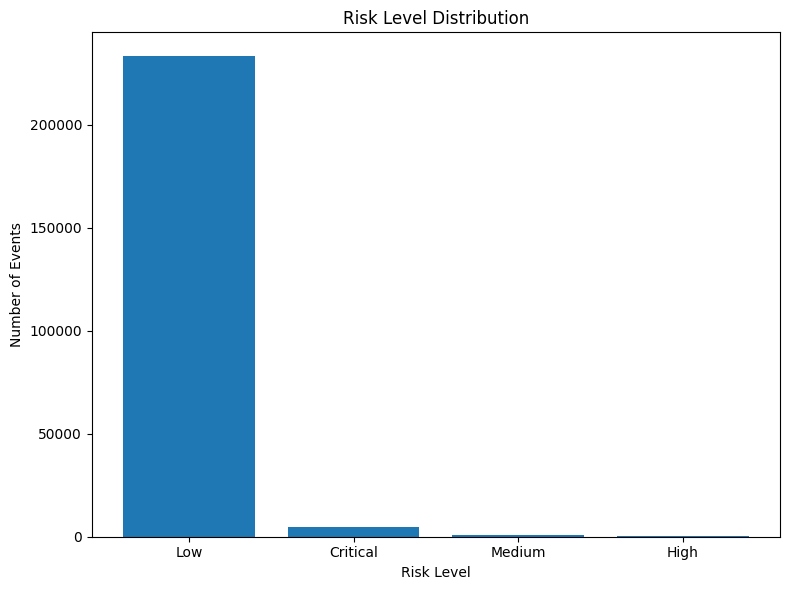

In [14]:
risk_counts = threat_report["RiskLevel"].value_counts()

plt.figure(figsize=(8,6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    "reports/figures/risk_level_distribution.png",
    dpi=300
)

plt.show()

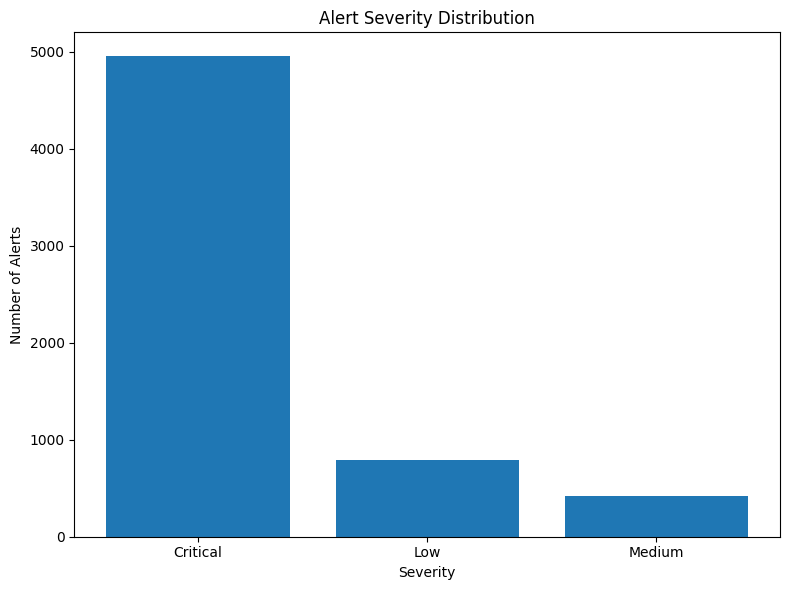

In [15]:
severity_counts = alerts["Severity"].value_counts()

plt.figure(figsize=(8,6))

plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.title("Alert Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Alerts")

plt.tight_layout()

plt.savefig(
    "reports/figures/alert_severity_distribution.png",
    dpi=300
)

plt.show()

In [16]:
summary = f"""
DeepTrace Model Evaluation Summary

Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC-AUC   : {roc_auc:.4f}

Confusion Matrix

TN : {cm[0,0]}
FP : {cm[0,1]}
FN : {cm[1,0]}
TP : {cm[1,1]}
"""

print(summary)

with open(
    "reports/metrics/evaluation_summary.txt",
    "w"
) as file:
    file.write(summary)

print("Evaluation summary saved successfully.")


DeepTrace Model Evaluation Summary

Accuracy  : 0.9941
Precision : 0.8823
Recall    : 0.8577
F1 Score  : 0.8698
ROC-AUC   : 0.9751

Confusion Matrix

TN : 233325
FP : 632
FN : 786
TP : 4737

Evaluation summary saved successfully.
